# Import Libraries

In [739]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


import warnings
warnings.filterwarnings('ignore')

# Load Data

In [793]:
%%time
df = pd.read_csv('CICIDS2018_top_26.csv')

print(f"Shape: {df.shape}")
print(f"Labels:\n{df['Label'].value_counts()}")

Shape: (748068, 26)
Labels:
Label
Bot                         100000
DDoS attacks-LOIC-HTTP      100000
Infilteration               100000
Benign                      100000
DDOS attack-HOIC            100000
DoS attacks-Hulk            100000
SSH-Bruteforce               94048
DoS attacks-GoldenEye        41406
DoS attacks-Slowloris         9908
DDOS attack-LOIC-UDP          1730
Brute Force -Web               555
Brute Force -XSS               228
SQL Injection                   84
DoS attacks-SlowHTTPTest        55
FTP-BruteForce                  54
Name: count, dtype: int64
CPU times: total: 3.75 s
Wall time: 3.84 s


### Prepare Features and Target

In [795]:
X = df.drop(columns=['Label'])
y = df['Label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

n_classes = len(le.classes_)
print(f"Number of classes: {n_classes}")
print(f"Classes: {list(le.classes_)}")

Number of classes: 15
Classes: ['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration', 'SQL Injection', 'SSH-Bruteforce']


### Train/Test Split

In [797]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (598454, 25)
Test size:  (149614, 25)


### Normalization (StandardScaler)

In [802]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)       

print("Scaling done")

Scaling done


### Convert Labels to Categorical (One-Hot Encoding)

In [805]:
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat  = to_categorical(y_test,  num_classes=n_classes)

print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"y_test_cat shape:  {y_test_cat.shape}")

y_train_cat shape: (598454, 15)
y_test_cat shape:  (149614, 15)


### Build the NN Model

In [808]:
model = Sequential([
    # Hidden Layer 1
    Dense(256, input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.15),

    # Hidden Layer 2
    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.15),

    # Hidden Layer 3
    Dense(64),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.15),

    # Output Layer
    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_104 (Dense)               │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_78 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_79 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_80          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_80 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,575 (197.56 KB)

 Trainable params: 49,679 (194.06 KB)

 Non-trainable params: 896 (3.50 KB)

### Define Callbacks & Train

In [811]:
%%time

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.1,
    epochs=70,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8760 - loss: 0.3238 - val_accuracy: 0.9110 - val_loss: 0.1742
Epoch 2/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9084 - loss: 0.1785 - val_accuracy: 0.9146 - val_loss: 0.1633
Epoch 3/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9116 - loss: 0.1677 - val_accuracy: 0.9165 - val_loss: 0.1578
Epoch 4/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9140 - loss: 0.1614 - val_accuracy: 0.9177 - val_loss: 0.1519
Epoch 5/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9147 - loss: 0.1580 - val_accuracy: 0.9165 - val_loss: 0.1528
Epoch 6/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9158 - loss: 0.1557 - val_accuracy: 0.9176 - val_loss: 0.1500
Epoch 7/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9166 - loss: 0.1538 - val_accuracy: 0.9183 - val_loss: 0.1479
Epoch 8/70
526/526 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9169 - loss: 0.1524 - 

### Plot Training History

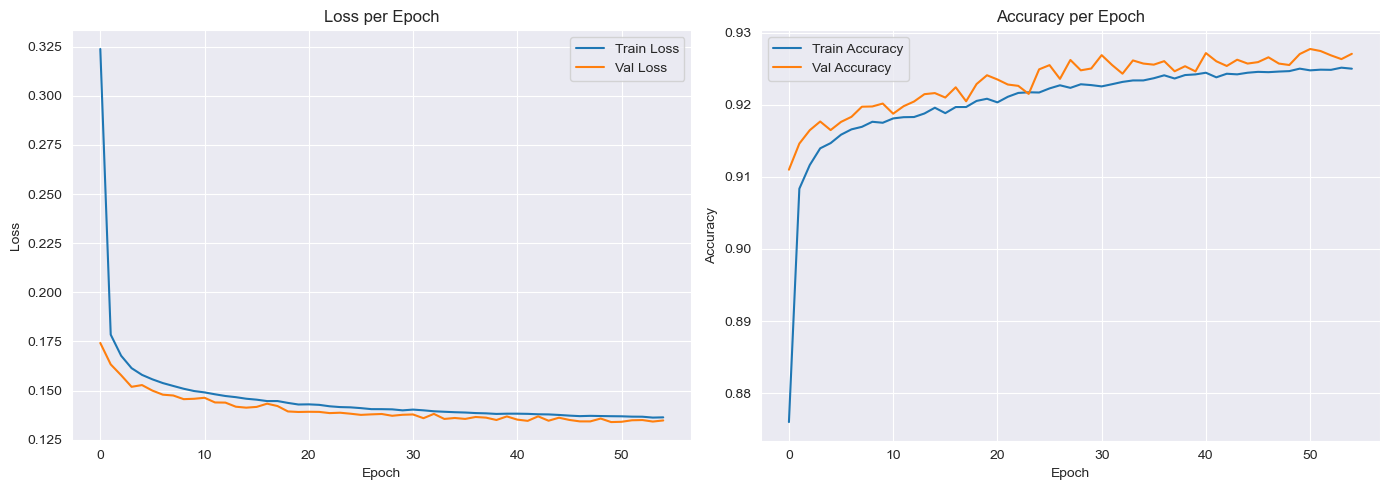

In [814]:
sns.set_style('darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Evaluate on Test Set

In [817]:
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

4676/4676 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
                          precision    recall  f1-score   support

                  Benign       0.81      0.61      0.70     20000
                     Bot       1.00      1.00      1.00     20000
        Brute Force -Web       0.80      0.74      0.77       111
        Brute Force -XSS       1.00      0.49      0.66        45
        DDOS attack-HOIC       1.00      1.00      1.00     20000
    DDOS attack-LOIC-UDP       0.96      1.00      0.98       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     20000
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     20000
DoS attacks-SlowHTTPTest       0.00      0.00      0.00        11
   DoS attacks-Slowloris       0.99      1.00      0.99      1982
          FTP-BruteForce       0.45      0.91      0.61        11
           Infilteration       0.69      0.85      0.76     20000
           SQL Injection       

### Confusion Matrix

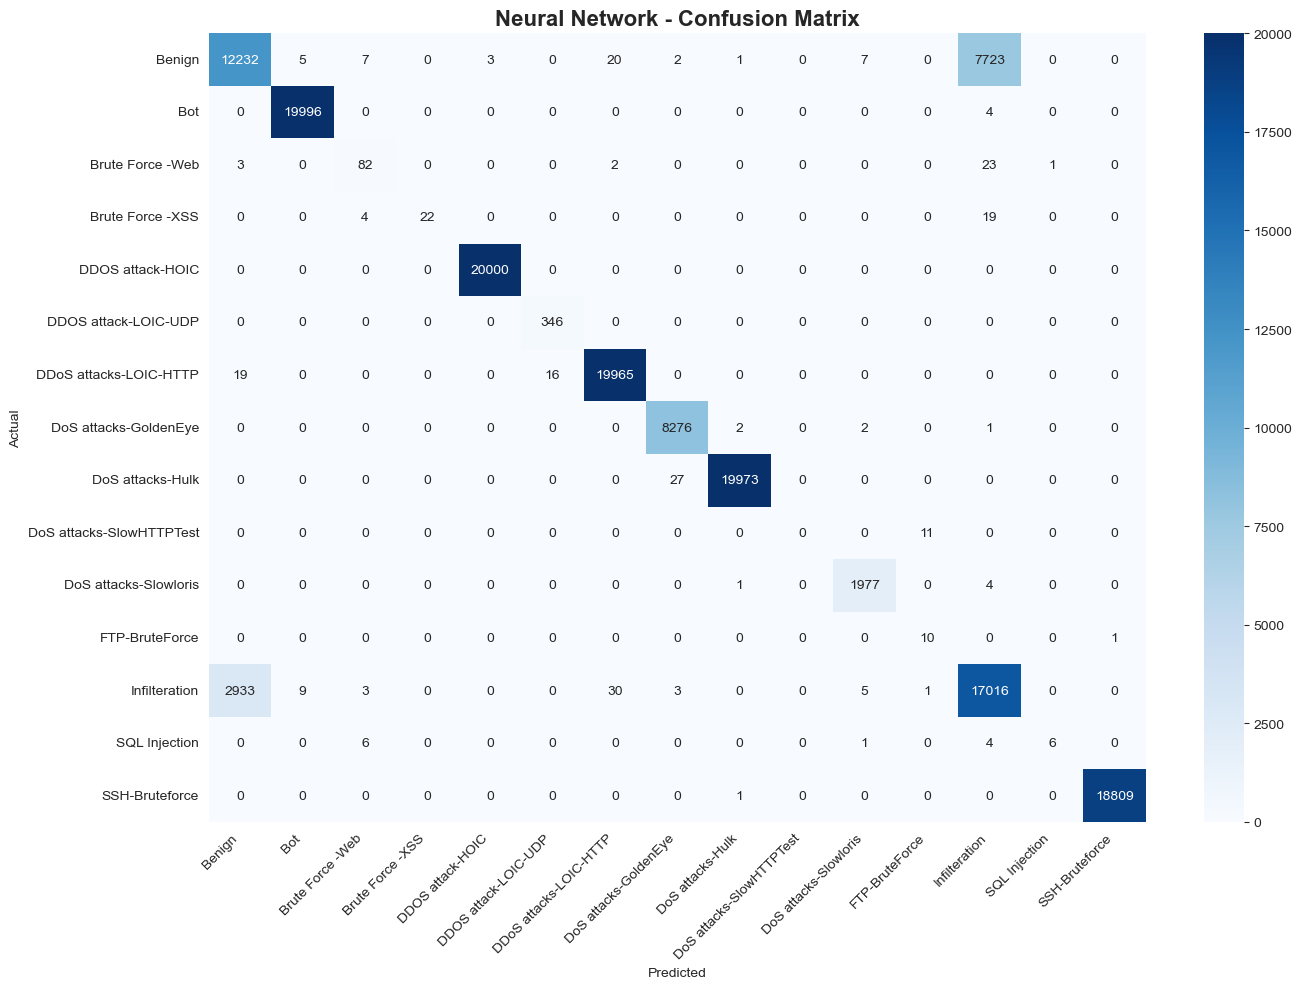

In [824]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Neural Network - Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('DNN_Confusion_Matrix.png', dpi=400)
plt.show()

### Save the Model and its dependencies

In [831]:
import joblib

# DNN model
model.save('dnn_model.keras')

# Scaler
joblib.dump(scaler, 'dnn_scaler.pkl')

# Label encoder
joblib.dump(le, 'dnn_label_encoder.pkl')

print("Saved: dnn_model.h5, dnn_scaler.pkl, dnn_label_encoder.pkl")

Saved: dnn_model.h5, dnn_scaler.pkl, dnn_label_encoder.pkl


### Test the model on real world data 

In [1]:
import joblib
from tensorflow.keras.models import load_model


# Load real dataset
df_real = pd.read_csv('CICIDS2018_10Percent.csv')

# Clean column names from leading/trailing spaces)
df_real.columns = df_real.columns.str.strip()


# Select the same 26 columns used in training
selected_columns = ['Init Fwd Win Byts', 'Init Bwd Win Byts', 'Flow IAT Std',
       'Fwd Seg Size Min', 'Dst Port', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Act Data Pkts', 'Flow IAT Max', 'Flow IAT Mean', 'Fwd Pkts/s',
       'Flow Pkts/s', 'TotLen Bwd Pkts', 'Pkt Len Max', 'Bwd IAT Mean',
       'RST Flag Cnt', 'ECE Flag Cnt', 'Flow Duration', 'Fwd Pkt Len Max',
       'TotLen Fwd Pkts', 'Active Mean', 'Down/Up Ratio', 'Fwd URG Flags',
       'Protocol', 'Flow Byts/s', 'Label']

df_real = df_real[selected_columns]

X_real = df_real.drop(columns=['Label'])
y_real_raw = df_real['Label']

print("Real data shape:", X_real.shape)


# Replace infinite values with 0 (instead of dropping rows)
inf_count = np.isinf(X_real.values).sum()
print("Infinite values found:", inf_count)

X_real = X_real.replace([np.inf, -np.inf], 0)

# Just in case there are also genuine NaNs (not from inf), fill those with 0 too
nan_count = X_real.isna().sum().sum()
print("NaN values found:", nan_count)
X_real = X_real.fillna(0)

print("Real data shape after cleaning:", X_real.shape)
print("Class distribution:\n", y_real_raw.value_counts())

# ===========================
# DNN evaluation
# ===========================
dnn_model = load_model('dnn_model.keras')
dnn_scaler = joblib.load('dnn_scaler.pkl')
dnn_le = joblib.load('dnn_label_encoder.pkl')

X_real_scaled = dnn_scaler.transform(X_real)
y_real_dnn = dnn_le.transform(y_real_raw)

dnn_probs = dnn_model.predict(X_real_scaled)
dnn_preds = np.argmax(dnn_probs, axis=1)

print("\n========== DNN ==========")
print(classification_report(y_real_dnn, dnn_preds, target_names=dnn_le.classes_, zero_division=0))

Real data shape: (1198955, 25)
Infinite values found: 10257
NaN values found: 4515
Real data shape after cleaning: (1198955, 25)
Class distribution:
 Label
Benign                      1063690
DDoS attacks-LOIC-HTTP        57536
DDOS attack-HOIC              19886
DoS attacks-Hulk              14520
Bot                           14454
Infilteration                 14061
SSH-Bruteforce                 9405
DoS attacks-GoldenEye          4141
DoS attacks-Slowloris           991
DDOS attack-LOIC-UDP            173
Brute Force -Web                 56
Brute Force -XSS                 23
SQL Injection                     8
DoS attacks-SlowHTTPTest          6
FTP-BruteForce                    5
Name: count, dtype: int64


C:\Users\A D M I N\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


37468/37468 ━━━━━━━━━━━━━━━━━━━━ 99s 3ms/step

========== DNN ==========
                          precision    recall  f1-score   support

                  Benign       1.00      0.61      0.75   1063690
                     Bot       0.97      1.00      0.99     14454
        Brute Force -Web       0.08      0.79      0.15        56
        Brute Force -XSS       0.82      0.39      0.53        23
        DDOS attack-HOIC       1.00      1.00      1.00     19886
    DDOS attack-LOIC-UDP       0.71      1.00      0.83       173
  DDoS attacks-LOIC-HTTP       0.98      1.00      0.99     57536
   DoS attacks-GoldenEye       0.98      1.00      0.99      4141
        DoS attacks-Hulk       1.00      1.00      1.00     14520
DoS attacks-SlowHTTPTest       0.00      0.00      0.00         6
   DoS attacks-Slowloris       0.76      1.00      0.86       991
          FTP-BruteForce       0.15      0.80      0.26         5
           Infilteration       0.03      0.85      0.05     14061
  